In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\basic1.csv")

In [3]:
df=data.copy()

In [4]:
df=df.astype(int)

In [5]:
df.head(2)

,x,y,color
0,79,152,0
1,98,186,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9794 entries, 0 to 9793
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       9794 non-null   int64
 1   y       9794 non-null   int64
 2   color   9794 non-null   int64
dtypes: int64(3)
memory usage: 229.7 KB


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#upper = Q3 + 1.5 * IQR

In [10]:
q1=df["y"].quantile(0.25)
q3=df["y"].quantile(0.75)
IQR=q3-q1
max=q3+(IQR*1.5)

In [11]:
df=df[df["y"]<max]

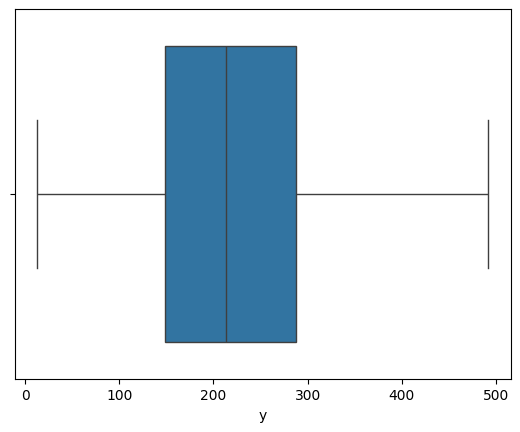

In [12]:
sns.boxplot(x="y",data=df)
plt.show()

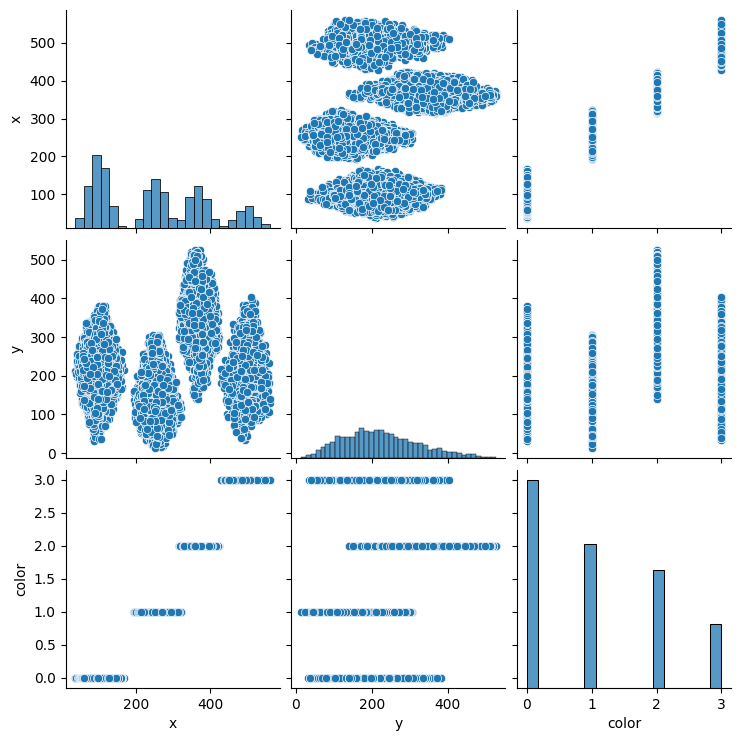

In [14]:
sns.pairplot(data=data)
plt.show()

In [15]:
#

In [16]:
df.drop(columns="color",inplace=True)

In [17]:
from sklearn.cluster import KMeans

In [18]:
df

,x,y
0,79,152
1,98,186
2,240,48
3,109,277
4,249,229
...,...,...
9789,271,152
9790,374,424
9791,496,317
9792,484,251


In [19]:
list=[]

In [20]:
list=[]
for i in range(1,20):
    km=KMeans(init='k-means++',n_clusters=i)
    km.fit(df)
    list.append(km.inertia_)

plt.plot([i for i in range(1,20)],list,marker="o")
plt.xlabel("number cluster ")
plt.xticks([i for i in range(1,20)])
plt.grid(axis="x")
plt.show()

In [21]:
km1=KMeans(n_clusters=4,init='k-means++')

In [22]:
km1.fit_predict(df)

array([0, 0, 2, ..., 1, 1, 3], shape=(9075,), dtype=int32)

In [23]:
df

,x,y
0,79,152
1,98,186
2,240,48
3,109,277
4,249,229
...,...,...
9789,271,152
9790,374,424
9791,496,317
9792,484,251


In [24]:
import scipy.cluster.hierarchy as sc

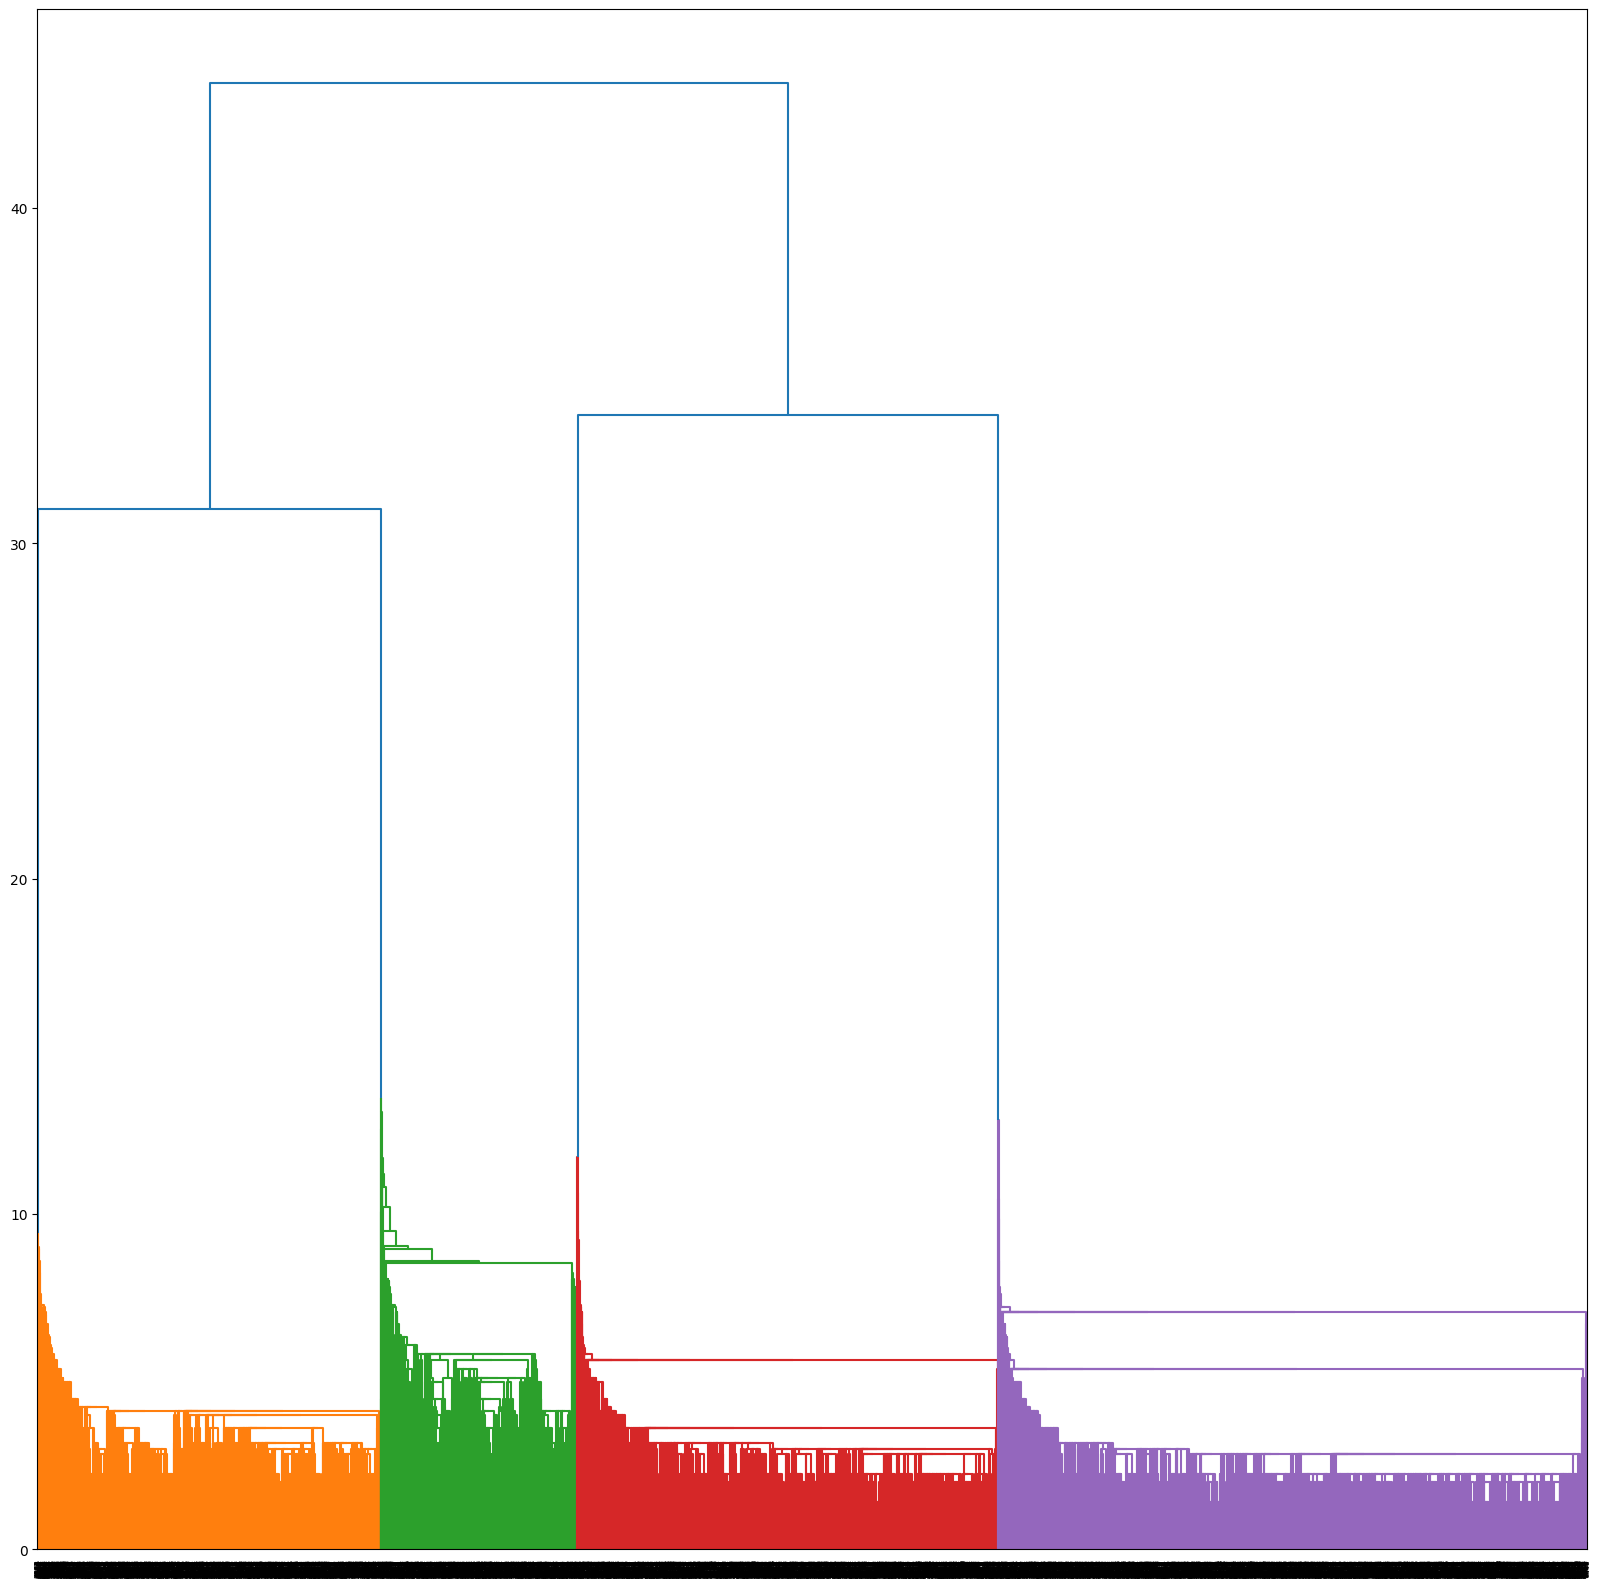

In [25]:
plt.figure(figsize=(20,20))
sc.dendrogram(sc.linkage(df,method="single",metric="euclidean"))
plt.show()

In [26]:
from sklearn.cluster import DBSCAN

In [27]:
db=DBSCAN(eps=0.2,min_samples=3)


In [28]:
df["pre"]=db.fit_predict(df)

In [29]:
df.tail(10)

,x,y,pre
9784,347,403,-1
9785,215,209,-1
9786,355,330,-1
9787,145,295,-1
9788,127,198,-1
9789,271,152,-1
9790,374,424,-1
9791,496,317,-1
9792,484,251,-1
9793,358,445,-1
